In [26]:
import pandas as pd
import numpy as np
from pandas import read_csv


df = read_csv("ai4i2020.csv")

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [28]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [29]:
# there is no missing values 
# there are only two categarial features which are porduct id and type (L, M, H)
# there are a targets which are machine failure , this target combines the different types of failures possible in a machine 
# like TWF, HDF, PWF, OSF, RNF
#Machine failure
#0    9661
#1     339

In [30]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [31]:
df[[
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]].groupby("Machine failure").sum()

,TWF,HDF,PWF,OSF,RNF
Machine failure,,,,,
0,0,0,0,0,18
1,46,115,95,98,1


In [32]:
df[[
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]].corr()

,Machine failure,TWF,HDF,PWF,OSF,RNF
Machine failure,1.000000,0.362904,0.575800,0.522812,0.531083,0.004516
TWF,0.362904,1.000000,-0.007332,0.008577,0.038243,0.030970
HDF,0.575800,-0.007332,1.000000,0.018443,0.046396,-0.004706
PWF,0.522812,0.008577,0.018443,1.000000,0.115836,-0.004273
OSF,0.531083,0.038243,0.046396,0.115836,1.000000,-0.004341
RNF,0.004516,0.030970,-0.004706,-0.004273,-0.004341,1.000000


In [33]:
print(df["Product ID"].nunique())
print(df["Product ID"].head(20).tolist())

10000
['M14860', 'L47181', 'L47182', 'L47183', 'L47184', 'M14865', 'L47186', 'L47187', 'M14868', 'M14869', 'H29424', 'H29425', 'M14872', 'M14873', 'L47194', 'L47195', 'M14876', 'M14877', 'H29432', 'M14879']


In [34]:
# definig our features
features = ['Type', 'Air temperature [K]','Process temperature [K]', 
            'Rotational speed [rpm]','Torque [Nm]','Tool wear [min]'
              ]
# our target , we can't use the other like TWF , and HDF because it won't be an available information during deployment also
# gives the model direct info that the machine has failure
target = 'Machine failure'

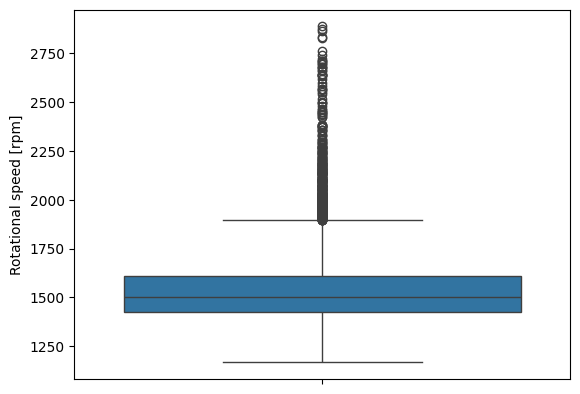

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data= df['Rotational speed [rpm]'] )
plt.show()

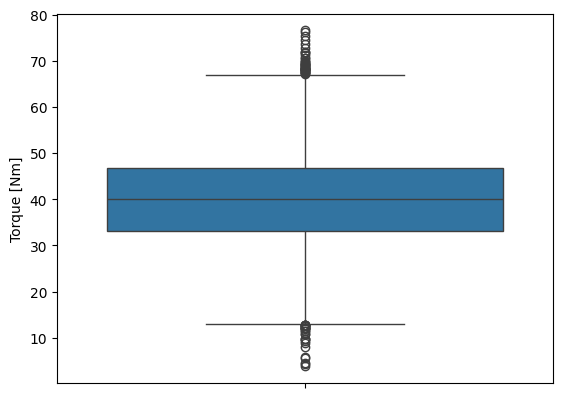

In [36]:
sns.boxplot(data=df['Torque [Nm]'])
plt.show()

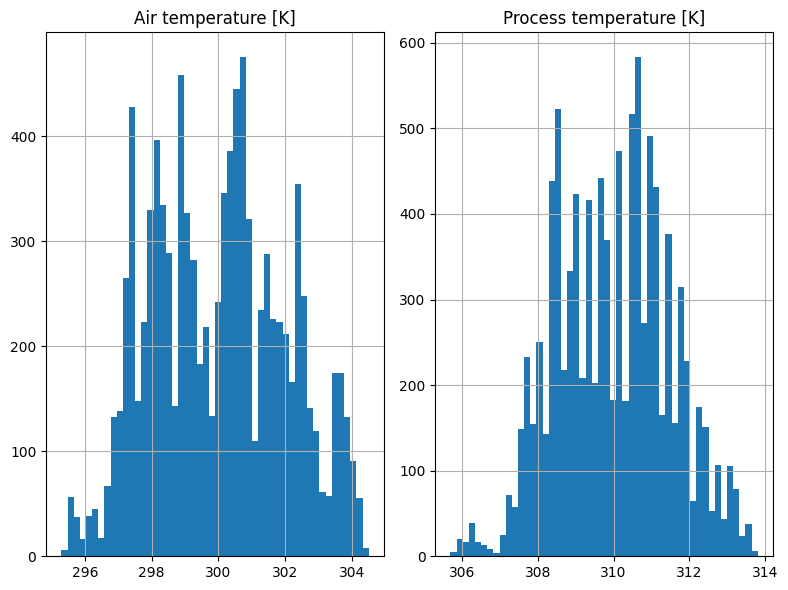

In [37]:
df[['Air temperature [K]', 'Process temperature [K]']].hist(figsize=(8, 6), bins= 50)
plt.tight_layout()
plt.show()

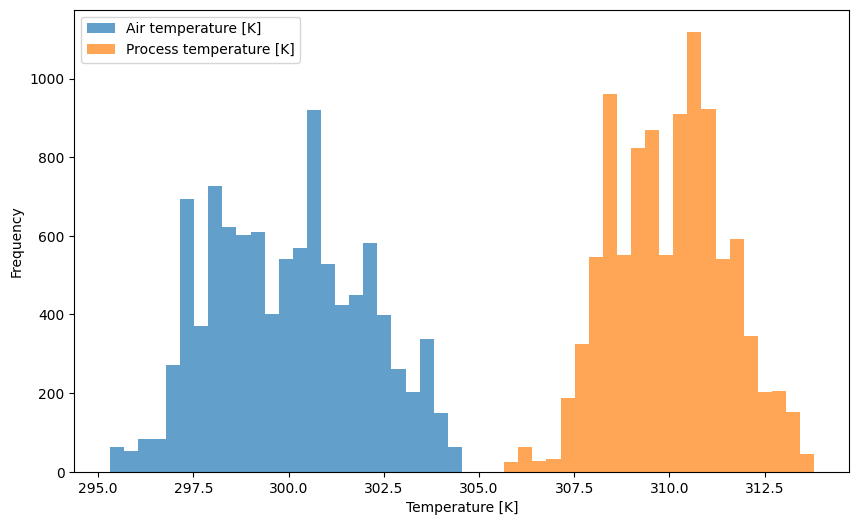

In [38]:
df[['Air temperature [K]', 'Process temperature [K]']].plot.hist(
    figsize=(10, 6), 
    bins=50, 
    alpha=0.7
)
plt.xlabel('Temperature [K]')
plt.show()

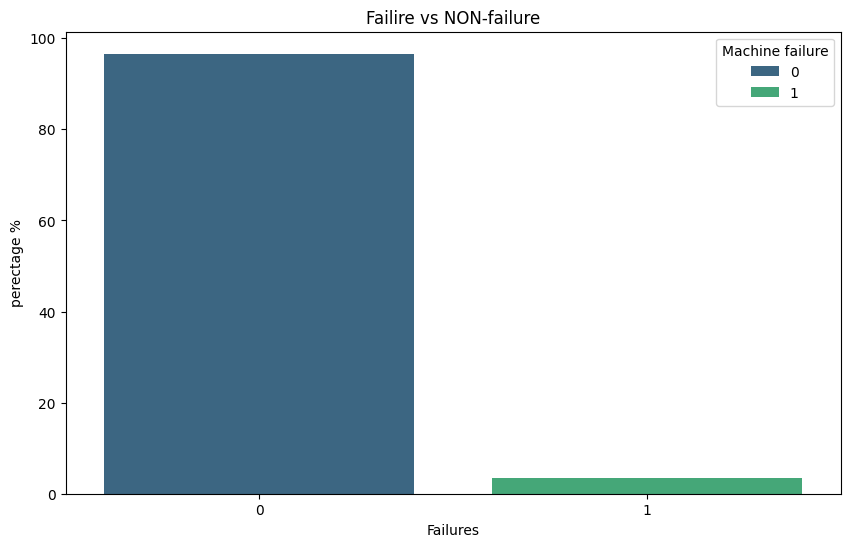

In [39]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x ='Machine failure', stat='percent', hue='Machine failure', palette='viridis')

plt.title('Failire vs NON-failure')
plt.xlabel("Failures")
plt.ylabel("perectage %")
plt.show()

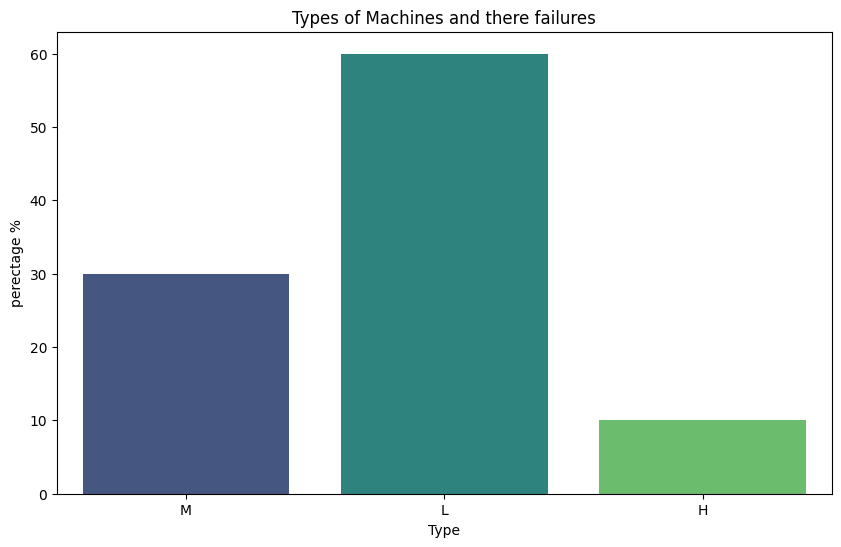

In [40]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x ='Type', stat='percent', hue='Type', palette='viridis')

plt.title('Types of Machines and there failures')
plt.xlabel("Type")
plt.ylabel("perectage %")
plt.show()

### Split and preprocessing


In [41]:
x = df[features].copy()
y = df[target].copy()

print("X shape: ", x.shape)
print("Y shape: ", y.shape)

X shape:  (10000, 6)
Y shape:  (10000,)


In [42]:
x.dtypes

Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
dtype: object

In [43]:
y.value_counts(normalize=True)

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

In [44]:
from sklearn.model_selection import train_test_split

x_train , x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42, stratify=y)

print("Training set:", x_train.shape)
print("Test set:", x_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (8000, 6)
Test set: (2000, 6)

Training target distribution:
Machine failure
0    0.966125
1    0.033875
Name: proportion, dtype: float64

Test target distribution:
Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)
results_tracker = []

def evaluation(model_name, parameters, y_test, y_pred, y_prob):
  
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_prob)
    pr = average_precision_score(y_test, y_prob)
    
    print(f"--- Results for: {model_name} ({parameters}) ---")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1       :", f1)
    print("ROC-AUC  :", roc)
    print("PR-AUC   :", pr)
    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("-" * 40)
    
    # Append the stored variables to the tracker list
    results_tracker.append({
        'Model': model_name,
        'Parameters': parameters,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC-AUC': roc,
        'PR-AUC': pr
    })

#### Lets try a dummy model to see how our data fits and how to imporve it

In [46]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dummy = DummyClassifier(
    strategy="most_frequent"
)

dummy.fit(x_train, y_train)

y_pred_dummy = dummy.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("Precision:", precision_score(y_test, y_pred_dummy, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_dummy, zero_division=0))
print("F1:", f1_score(y_test, y_pred_dummy, zero_division=0))

Accuracy: 0.966
Precision: 0.0
Recall: 0.0
F1: 0.0


### Logistic Regression


In [47]:
# preprocessing the data

from cv2 import transform
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

categorical_features = ["Type"]
numerical_features =['Air temperature [K]','Process temperature [K]', 
            'Rotational speed [rpm]','Torque [Nm]','Tool wear [min]'
              ]
para_log = ["max_iter=1000","random_state=42"]
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num", 
            StandardScaler(),
            numerical_features

        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)
logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42, n_jobs=-1
        ))
    ]
)


In [48]:
logistic_model.fit(x_train, y_train)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [49]:
y_pred_logreg = logistic_model.predict(x_test)
y_prob_logreg = logistic_model.predict_proba(x_test)[:, 1]

In [50]:
evaluation('Logistic Regression',para_log ,y_test, y_pred_logreg, y_prob_logreg)

--- Results for: Logistic Regression (['max_iter=1000', 'random_state=42']) ---
Accuracy : 0.9675
Precision: 0.6363636363636364
Recall   : 0.10294117647058823
F1       : 0.17721518987341772
ROC-AUC  : 0.8993880160759956
PR-AUC   : 0.4205369579251732

Confusion matrix:
[[1928    4]
 [  61    7]]
----------------------------------------


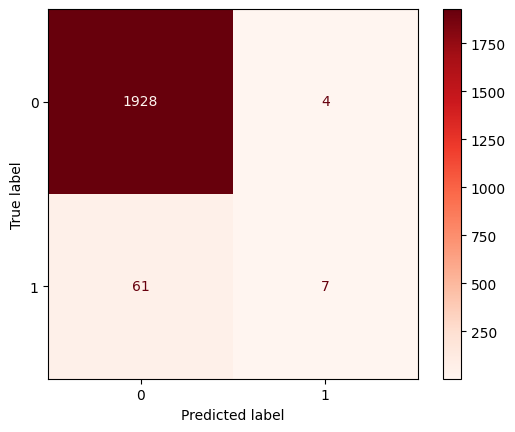

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions( y_test, y_pred_logreg, 
                                        cmap='Reds')
plt.show()

##### The results is very poor it can only detect 7 positvies or machine failures and has a recall of 10% which is very bad. We now are going to experiment with a non-linear model such as trees

## Decision Tree based model


##### Because the target variable is highly imbalanced, accuracy alone is insufficient for evaluating the classifier. We therefore used F1-score as the primary optimization metric because it jointly evaluates precision and recall. Five-fold cross-validation was used on the training set to search for a Decision Tree configuration while keeping the test set completely untouched.

In [52]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__max_depth": [2, 3, 4, 5, 6, 7, 8, 10, 12, None],

    "classifier__min_samples_split": [2, 5, 10, 20, 30],

    "classifier__min_samples_leaf": [1, 2, 3, 5, 10, 15],

    "classifier__criterion": [
        "gini",
        "entropy",
        "log_loss"
    ],

    "classifier__class_weight": [
        None,
        "balanced",
        {0: 1, 1: 2},
        {0: 1, 1: 3},
        {0: 1, 1: 5},
        {0: 1, 1: 10}
    ]
}
decisionTree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ("classifier", 
            DecisionTreeClassifier(random_state=42)
                                    )

    ]
)
grid_search = GridSearchCV(
    estimator=decisionTree_model,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1, 
)

grid_search.fit(x_train, y_train)


Fitting 5 folds for each of 5400 candidates, totalling 27000 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__class_weight': [None, 'balanced', ...], 'classifier__criterion': ['gini', 'entropy', ...], 'classifier__max_depth': [2, 3, ...], 'classifier__min_samples_leaf': [1, 2, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [53]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV F1:")
print(grid_search.best_score_)

Best parameters:
{'classifier__class_weight': {0: 1, 1: 2}, 'classifier__criterion': 'entropy', 'classifier__max_depth': 8, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5}

Best CV F1:
0.7321412657123428


##### we now take our best parameters and train it and explore more of its evaluation metrics also save our results in the result_tracker

In [54]:
decisionTree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ("classifier", 
            DecisionTreeClassifier(random_state=42, class_weight={0:1, 1:2}, criterion='entropy'
                                   , max_depth=8, min_samples_leaf=2 , min_samples_split=5)
                                    )

    ]
)
decisionTree_model.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [55]:
y_pred_tree = decisionTree_model.predict(x_test)
y_prob_tree = decisionTree_model.predict_proba(x_test)[:, 1]

In [56]:
evaluation('DecisionTreeClassifier', grid_search.best_score_, y_test, y_pred_tree, y_prob_tree)

--- Results for: DecisionTreeClassifier (0.7321412657123428) ---
Accuracy : 0.9825
Precision: 0.7619047619047619
Recall   : 0.7058823529411765
F1       : 0.732824427480916
ROC-AUC  : 0.8900103519668737
PR-AUC   : 0.6766467477744124

Confusion matrix:
[[1917   15]
 [  20   48]]
----------------------------------------


#### so this is a really good results for the decision tree classifier we can explore and experiment with more non-linear model like the following . also the tree model shows a good recal and f1 scores it only classifies 20 wrong from the positive class and 15 from the negative class which pretty decent considering the reallllly unbalanced data

##### The nonlinear Decision Tree substantially improves positive-class prediction compared with Logistic Regression, particularly in the precision-recall tradeoff. Hyperparameter tuning further reduces false positives while retaining most of the model's ability to detect failures

## Random Forest

In [57]:
from sklearn.ensemble import RandomForestClassifier
rf_param_grid = {
    "classifier__n_estimators": [100, 200, 400],

    "classifier__max_depth": [
        None,
        5,
        10,
        15
    ],

    "classifier__min_samples_split": [
        2,
        5,
        10
    ],

    "classifier__min_samples_leaf": [
        1,
        2,
        5
    ],

    "classifier__max_features": [
        "sqrt",
        "log2"
    ],

    "classifier__class_weight": [
        None,
        "balanced",
        {0: 1, 1: 3},
        {0: 1, 1: 5}
    ]
}

RF_model = Pipeline(
    steps= [
            ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42, 
                                             n_jobs=-1, 
                                             verbose= 1))
    ]
)

grid_search_RF = GridSearchCV(
    estimator= RF_model,
    scoring = "f1",
    n_jobs=-1,
    return_train_score=True,
    verbose= 2,
    param_grid= rf_param_grid,
    cv =5
)

In [58]:
grid_search_RF.fit(x_train, y_train)

Fitting 5 folds for each of 864 candidates, totalling 4320 fits


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:    1.9s finished


,estimator,Pipeline(step... verbose=1))])
,param_grid,"{'classifier__class_weight': [None, 'balanced', ...], 'classifier__max_depth': [None, 5, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': [1, 2, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [59]:
print("Best Parameters:\n", grid_search_RF.best_params_)
print("\nBest CV F1:\n ", grid_search_RF.best_score_)


Best Parameters:
 {'classifier__class_weight': {0: 1, 1: 5}, 'classifier__max_depth': None, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 400}

Best CV F1:
  0.7444806832346501


In [60]:
best_rf = grid_search_RF.best_estimator_
y_pred_rf = best_rf.predict(x_test)
y_prob_rf = best_rf.predict_proba(x_test)[:,1]

evaluation("Random Forest", grid_search_RF.best_params_ ,y_test, y_pred_rf, y_prob_rf)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 400 out of 400 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s


--- Results for: Random Forest ({'classifier__class_weight': {0: 1, 1: 5}, 'classifier__max_depth': None, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 400}) ---
Accuracy : 0.9855
Precision: 0.8421052631578947
Recall   : 0.7058823529411765
F1       : 0.768
ROC-AUC  : 0.9641563146997929
PR-AUC   : 0.8072880347289209

Confusion matrix:
[[1923    9]
 [  20   48]]
----------------------------------------


[Parallel(n_jobs=12)]: Done 400 out of 400 | elapsed:    0.1s finished


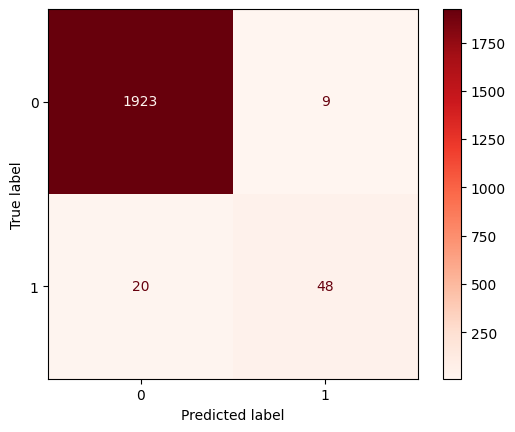

In [61]:
ConfusionMatrixDisplay.from_predictions( y_test, y_pred_rf, 
                                        cmap='Reds')
plt.show()

In [62]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.52, 0.54 ,0.56]

for threshold in thresholds:
    y_pred_threshold = (y_prob_rf >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.20 | Precision: 0.420 | Recall: 0.882 | F1: 0.569
Threshold: 0.25 | Precision: 0.460 | Recall: 0.838 | F1: 0.594
Threshold: 0.30 | Precision: 0.538 | Recall: 0.824 | F1: 0.651
Threshold: 0.35 | Precision: 0.655 | Recall: 0.809 | F1: 0.724
Threshold: 0.40 | Precision: 0.711 | Recall: 0.794 | F1: 0.750
Threshold: 0.45 | Precision: 0.785 | Recall: 0.750 | F1: 0.767
Threshold: 0.50 | Precision: 0.842 | Recall: 0.706 | F1: 0.768
Threshold: 0.52 | Precision: 0.836 | Recall: 0.676 | F1: 0.748
Threshold: 0.54 | Precision: 0.863 | Recall: 0.647 | F1: 0.739
Threshold: 0.56 | Precision: 0.857 | Recall: 0.618 | F1: 0.718


#### I decided to do some feature engineering before going to the next model

In [63]:
from sklearn.model_selection import train_test_split
df["Torque_Speed_Ratio"] =( df["Torque [Nm]"] / df["Rotational speed [rpm]"])
df["Wear_Speed_Ratio"] = (df["Tool wear [min]"] / df["Rotational speed [rpm]"])
df["Temperature_Difference"] = (df["Air temperature [K]"] - df["Process temperature [K]"])

mod_features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Torque_Speed_Ratio",
    "Wear_Speed_Ratio",
    "Temperature_Difference"
]

x_new = df[mod_features].copy()
y = df["Machine failure"]
xn_train, xn_test, yn_train, yn_test = train_test_split(x_new, y, random_state=42, stratify=y , test_size=0.2)

In [85]:
xn_test.shape

(2000, 9)

In [64]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
ncategorical_features = ["Type"]
nnumerical_features =['Air temperature [K]','Process temperature [K]', 
            'Rotational speed [rpm]','Torque [Nm]','Tool wear [min]',"Torque_Speed_Ratio",
                "Wear_Speed_Ratio",
                "Temperature_Difference"
              ]
new_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num", 
            StandardScaler(),
            nnumerical_features

        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            ncategorical_features
        )
    ]
)

new_RF_model = Pipeline(
    steps= [
            ("preprocessor", new_preprocessor),
        ("classifier", RandomForestClassifier(random_state=42, 
                                             n_jobs=1, 
                                             verbose= 0))
    ]
)

new_grid_search_RF = GridSearchCV(
    estimator= new_RF_model,
    scoring = "f1",
    n_jobs=-1,
    return_train_score=True,
    verbose= 2,
    param_grid= rf_param_grid,
    cv =5
)

In [65]:
new_grid_search_RF.fit(xn_train, yn_train)

Fitting 5 folds for each of 864 candidates, totalling 4320 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__class_weight': [None, 'balanced', ...], 'classifier__max_depth': [None, 5, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': [1, 2, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [66]:
# 2. Best parameters
print("\nBest Parameters after Feat eng:",new_grid_search_RF.best_params_)

# 3. Best CV F1
print("\nBest F1 score after Feat ENG:",new_grid_search_RF.best_score_)

best_new_rf = new_grid_search_RF.best_estimator_
y_pred_rf_new = best_new_rf.predict(xn_test)
y_prob_rf_new = best_new_rf.predict_proba(xn_test)[:, 1]




Best Parameters after Feat eng: {'classifier__class_weight': {0: 1, 1: 5}, 'classifier__max_depth': 15, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

Best F1 score after Feat ENG: 0.7775899622617739


In [67]:
evaluation("New Rf model", new_grid_search_RF.best_params_, yn_test, y_pred_rf_new, y_prob_rf_new)

--- Results for: New Rf model ({'classifier__class_weight': {0: 1, 1: 5}, 'classifier__max_depth': 15, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}) ---
Accuracy : 0.988
Precision: 0.8793103448275862
Recall   : 0.75
F1       : 0.8095238095238095
ROC-AUC  : 0.9819753988551942
PR-AUC   : 0.834803896450141

Confusion matrix:
[[1925    7]
 [  17   51]]
----------------------------------------


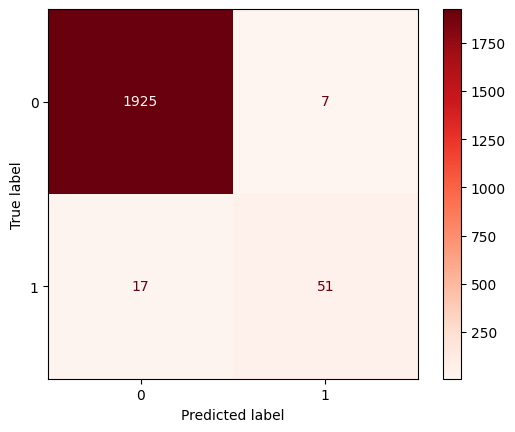

In [68]:
ConfusionMatrixDisplay.from_predictions( yn_test, y_pred_rf_new, 
                                        cmap='Reds')
plt.show()

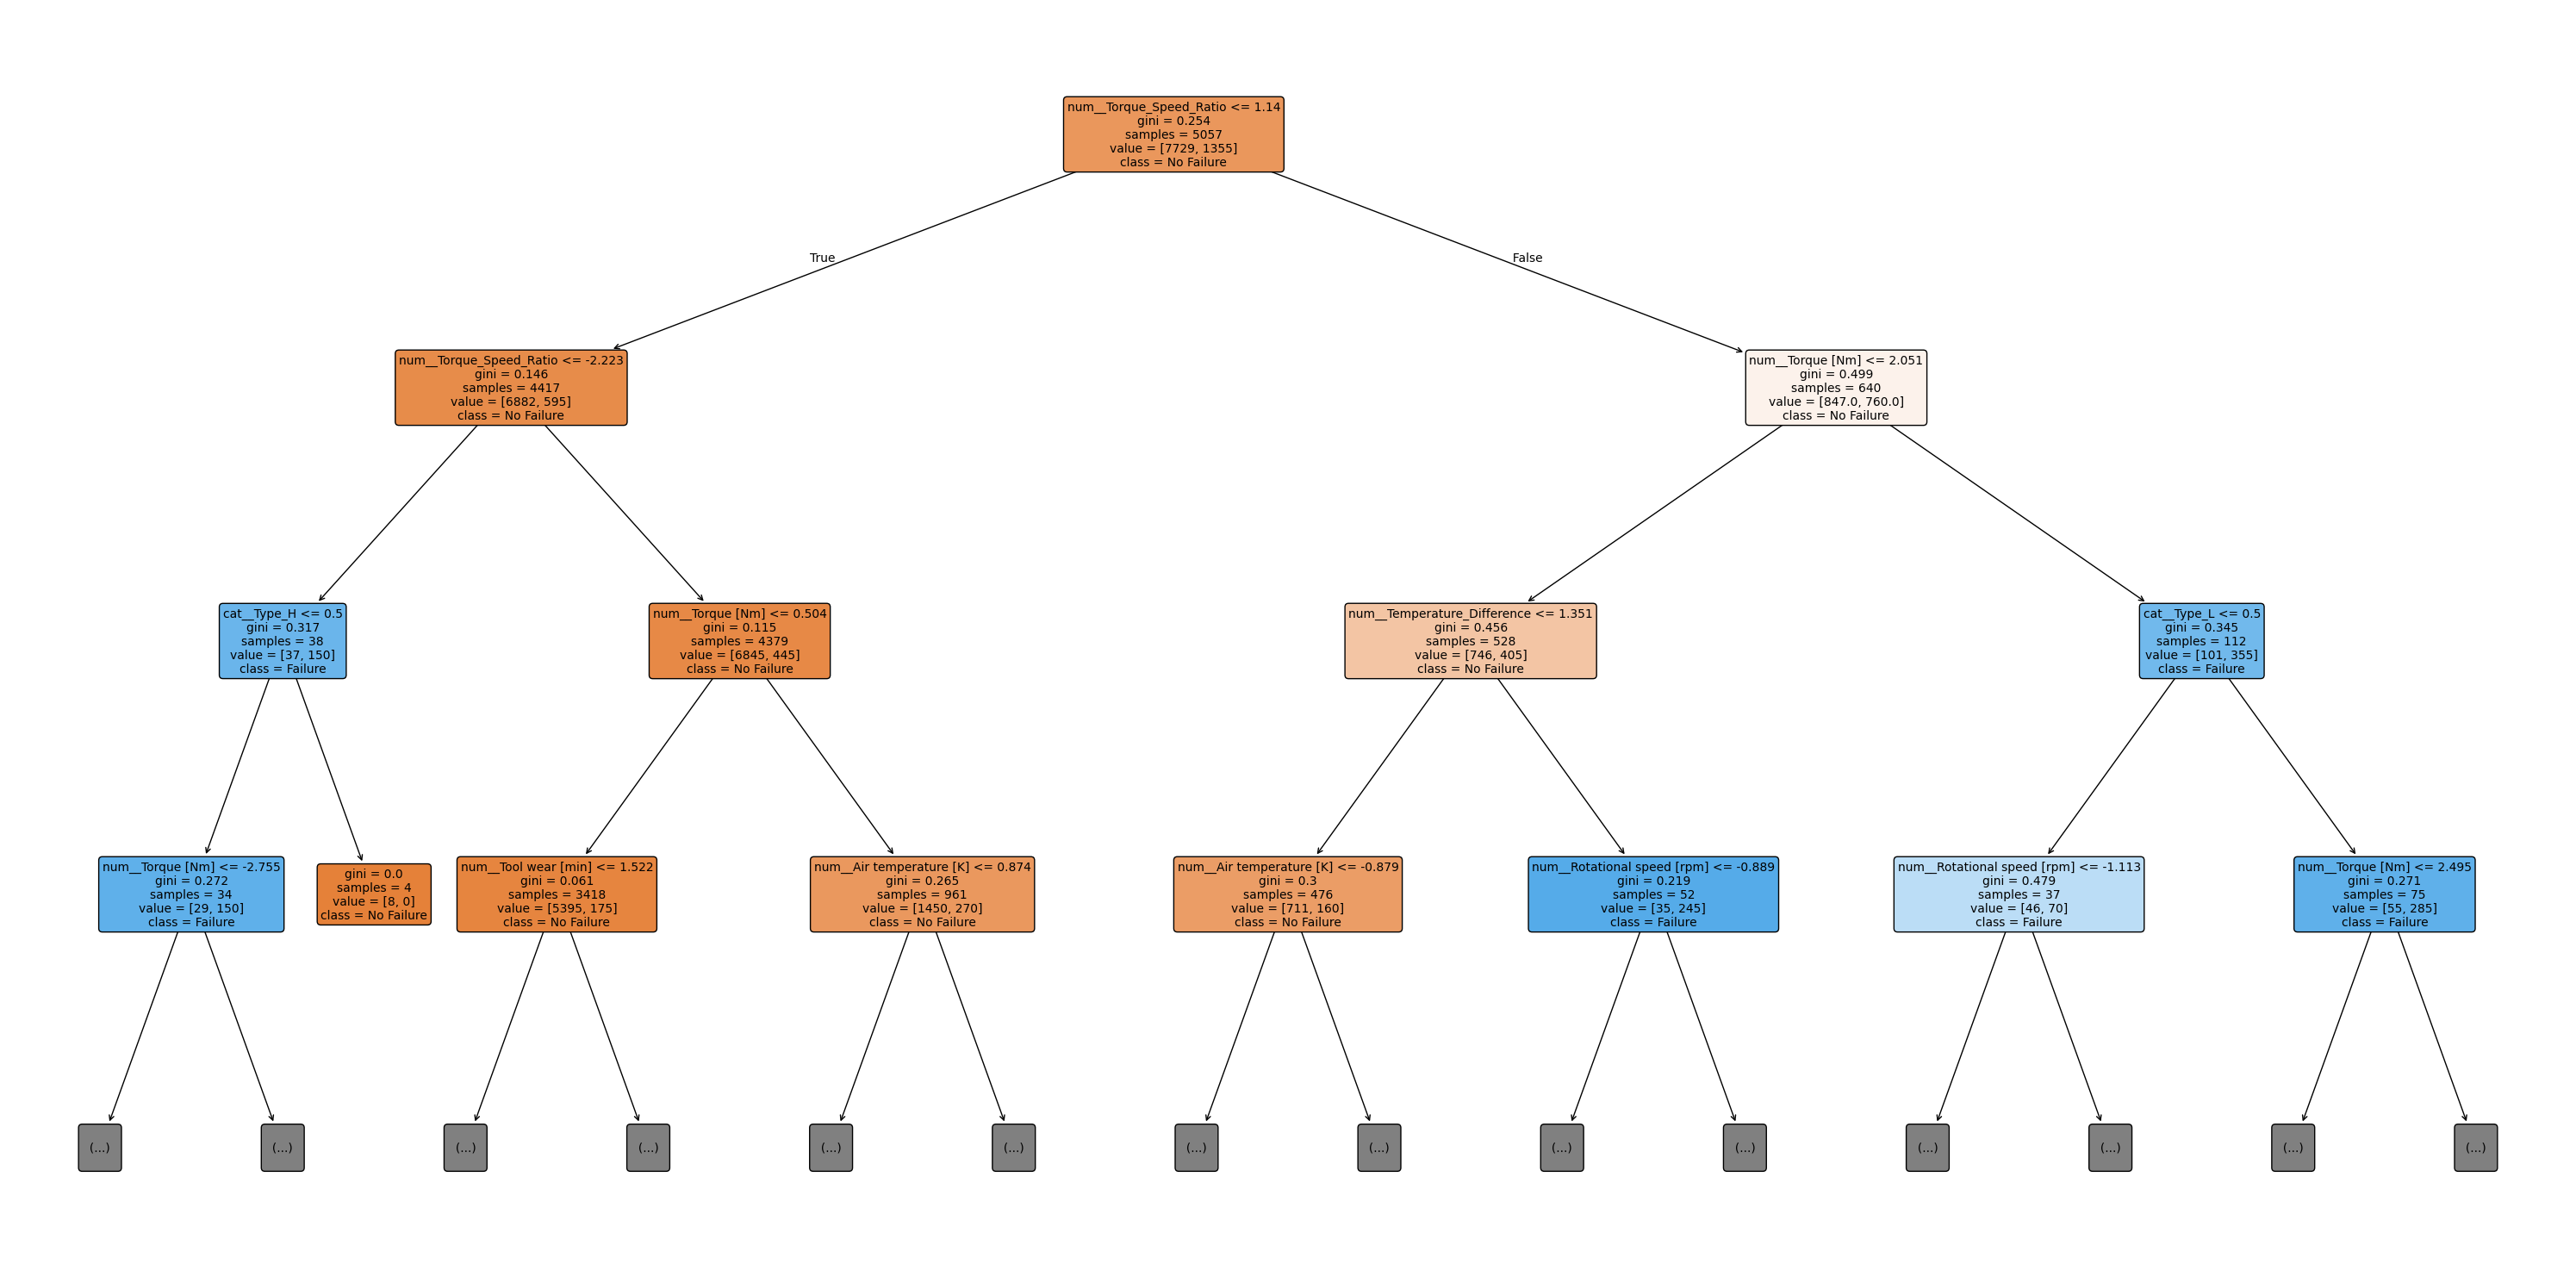

In [69]:
from sklearn.tree import plot_tree
feature_names = (
    new_grid_search_RF
    .best_estimator_
    .named_steps["preprocessor"]
    .get_feature_names_out()
)
tree = new_grid_search_RF.best_estimator_.named_steps["classifier"].estimators_[0]
plt.figure(figsize=(30, 15))

plot_tree(
    tree,
    feature_names=feature_names,
    class_names=["No Failure", "Failure"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)

plt.tight_layout()
plt.savefig("random_forest_tree.pdf", bbox_inches="tight")
plt.show()

### XGBoost classifier


In [70]:
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
ncategorical_features = ["Type"]
nnumerical_features =['Air temperature [K]','Process temperature [K]', 
            'Rotational speed [rpm]','Torque [Nm]','Tool wear [min]',"Torque_Speed_Ratio",
                "Wear_Speed_Ratio",
                "Temperature_Difference"
              ]
new_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num", 
            StandardScaler(),
            nnumerical_features

        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            ncategorical_features
        )
    ]
)



In [71]:
xgboost = Pipeline(
    steps=[
        ("preprocessing", new_preprocessor),
        ("classifier", XGBClassifier())
    ]
)
xgboost_param = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [3, 5, 7],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0],
    "classifier__gamma": [0, 1],
    "classifier__reg_alpha": [0, 1],
    "classifier__reg_lambda": [1, 2],
   ## "classifier__scale_pos_weight": [1, 5, 10, 20, 30]
}

xgboost_gridsearch = GridSearchCV(
    estimator=xgboost,
    param_grid= xgboost_param,
    cv=5 , 
    n_jobs=-1,
    scoring='f1',
    verbose=2
)

In [72]:
xgboost_gridsearch.fit(xn_train, yn_train)


Fitting 5 folds for each of 576 candidates, totalling 2880 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'classifier__colsample_bytree': [0.8, 1.0], 'classifier__gamma': [0, 1], 'classifier__learning_rate': [0.05, 0.1], 'classifier__max_depth': [3, 5, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [73]:
print("\nBest Parameters after Feat eng:",xgboost_gridsearch.best_params_)

# 3. Best CV F1
print("\nBest F1 score after Feat ENG:",xgboost_gridsearch.best_score_)


Best Parameters after Feat eng: {'classifier__colsample_bytree': 1.0, 'classifier__gamma': 1, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'classifier__reg_alpha': 0, 'classifier__reg_lambda': 1, 'classifier__subsample': 0.8}

Best F1 score after Feat ENG: 0.7824956082151894


In [74]:
best_xgboost = xgboost_gridsearch.best_estimator_
y_pred_xgb = best_xgboost.predict(xn_test)
y_prob_xgb = best_xgboost.predict_proba(xn_test)[:, 1]
evaluation("xgboost", xgboost_param, yn_test, y_pred_xgb, y_prob_xgb)

--- Results for: xgboost ({'classifier__n_estimators': [100, 200, 300], 'classifier__learning_rate': [0.05, 0.1], 'classifier__max_depth': [3, 5, 7], 'classifier__subsample': [0.8, 1.0], 'classifier__colsample_bytree': [0.8, 1.0], 'classifier__gamma': [0, 1], 'classifier__reg_alpha': [0, 1], 'classifier__reg_lambda': [1, 2]}) ---
Accuracy : 0.99
Precision: 0.9285714285714286
Recall   : 0.7647058823529411
F1       : 0.8387096774193549
ROC-AUC  : 0.9829192546583851
PR-AUC   : 0.8888799930859227

Confusion matrix:
[[1928    4]
 [  16   52]]
----------------------------------------


In [75]:
from transformers import MoshiConfig


results_df = pd.DataFrame(results_tracker)

results_df.to_csv("results.csv", index=False, header=False, mode="a")

In [76]:
correlation = df.corr(numeric_only=True)

correlation["Machine failure"].sort_values(ascending=False)

Machine failure            1.000000
HDF                        0.575800
OSF                        0.531083
PWF                        0.522812
TWF                        0.362904
Torque_Speed_Ratio         0.206493
Torque [Nm]                0.191321
Wear_Speed_Ratio           0.130213
Temperature_Difference     0.111676
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
RNF                        0.004516
UDI                       -0.022892
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64

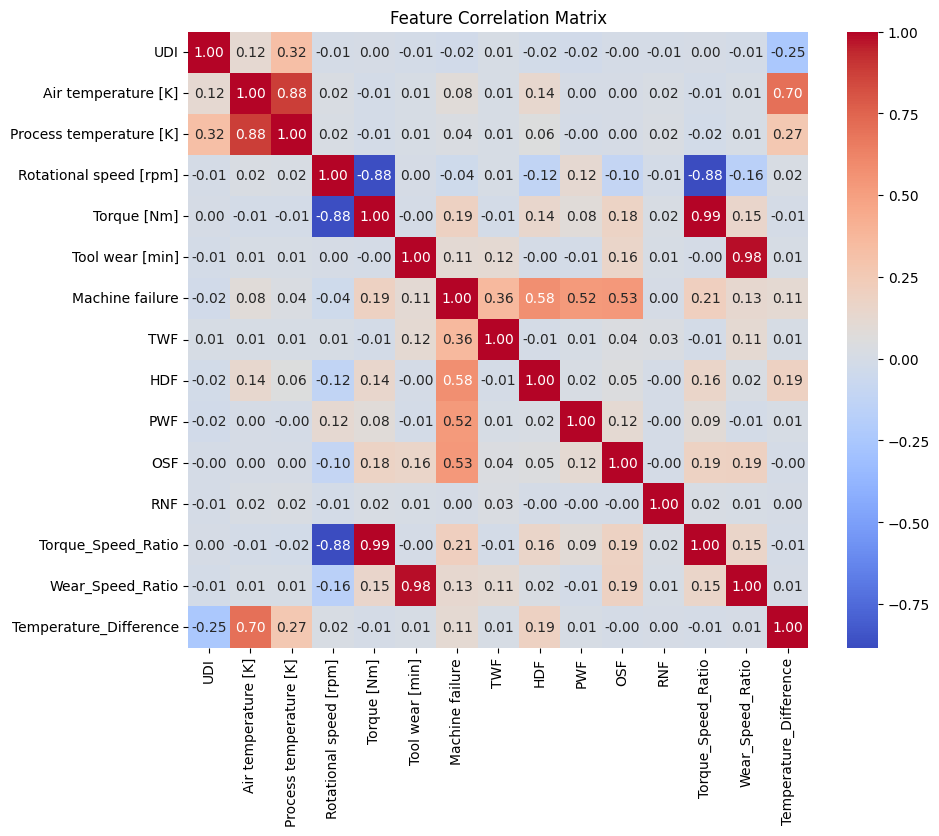

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

In [86]:
pre_processor = best_xgboost.named_steps["preprocessing"]
xgb_model= best_xgboost.named_steps["classifier"]

x_test_transformed = pre_processor.transform(xn_test)



In [87]:
feature_names = pre_processor.get_feature_names_out()

print(feature_names)


['num__Air temperature [K]' 'num__Process temperature [K]'
 'num__Rotational speed [rpm]' 'num__Torque [Nm]' 'num__Tool wear [min]'
 'num__Torque_Speed_Ratio' 'num__Wear_Speed_Ratio'
 'num__Temperature_Difference' 'cat__Type_H' 'cat__Type_L' 'cat__Type_M']


In [88]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(x_test_transformed)

In [89]:
print("x_test_transformed shape:", x_test_transformed.shape)
print("XGBoost n_features_in_:", xgb_model.n_features_in_)

x_test_transformed shape: (2000, 11)
XGBoost n_features_in_: 11


In [90]:
print(type(x_test_transformed))
print(xgb_model.get_booster().num_features())

<class 'numpy.ndarray'>
11


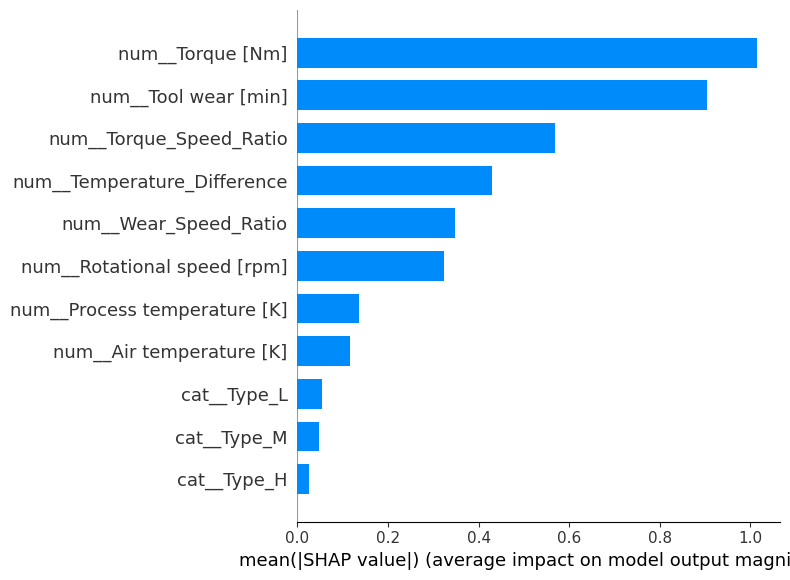

In [91]:
shap.summary_plot(
    shap_values,
    x_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

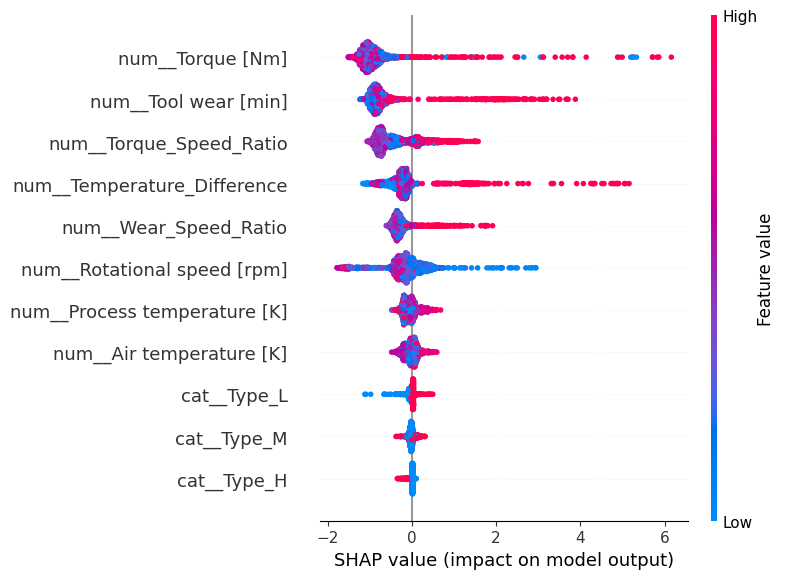

In [92]:
shap.summary_plot(
    shap_values,
    x_test_transformed,
    feature_names=feature_names
)

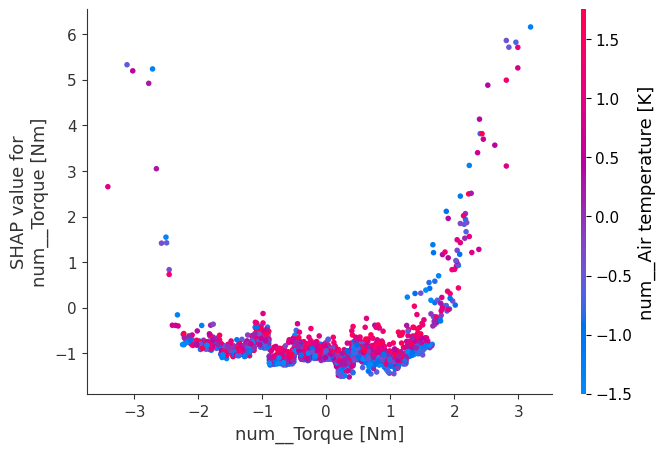

In [100]:
shap.dependence_plot(
    "num__Torque [Nm]",
    shap_values,
    x_test_transformed,
    feature_names=feature_names
)

In [103]:
print(type(x_test_transformed))

<class 'numpy.ndarray'>


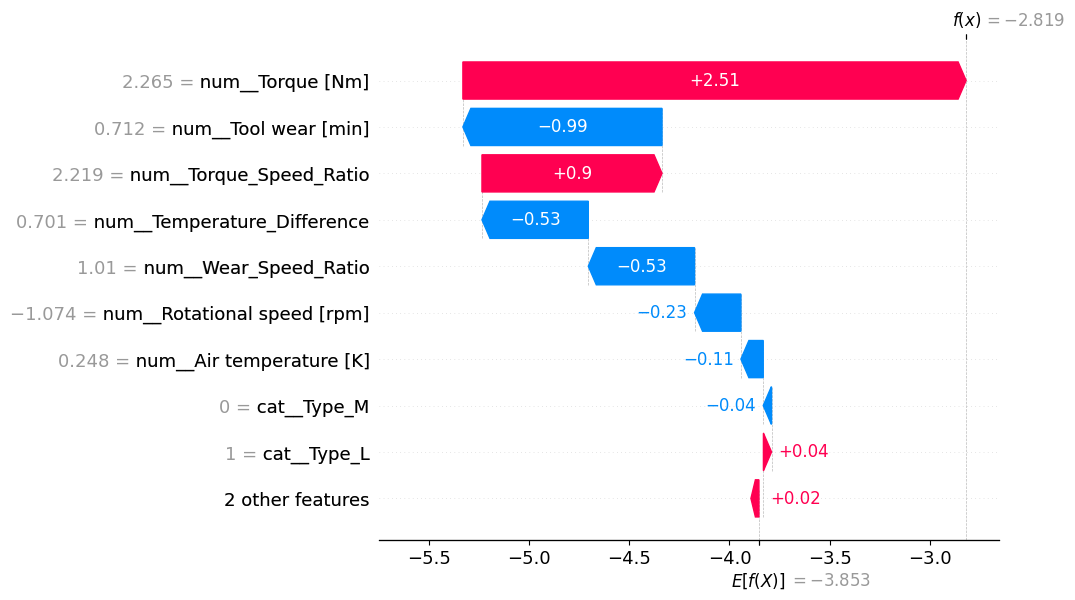

In [104]:
i = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=x_test_transformed[i],
        feature_names=feature_names
    )
)